In [5]:
# ============================================
# CELL 1: Install libraries & unzip dataset
# ============================================
!pip install pypdf -q

import zipfile
import os

# unzip the uploaded dataset (make sure nlp_dataset_50pdfs.zip is in Colab's file section)
with zipfile.ZipFile("nlp_dataset_50pdfs.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

# check folder structure
for category in sorted(os.listdir("dataset/data")):
    path = f"dataset/data/{category}"
    print(category, "->", len(os.listdir(path)), "files")

faith_and_belief -> 11 files
life_and_pessimism -> 11 files
rationality_philosophy -> 16 files
theism_and_mind -> 12 files


In [6]:
# ============================================
# CELL 2: Extract raw text from all 50 PDFs
# ============================================
from pypdf import PdfReader
import pandas as pd

DATA_DIR = "dataset/data"
records = []

for category in sorted(os.listdir(DATA_DIR)):
    category_path = os.path.join(DATA_DIR, category)
    for filename in sorted(os.listdir(category_path)):
        filepath = os.path.join(category_path, filename)
        try:
            reader = PdfReader(filepath)
            text = ""
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + " "
            records.append({
                "file_name": filename,
                "category": category,
                "raw_text": text.strip()
            })
        except Exception as e:
            print(f"Failed on {filename}: {e}")

df = pd.DataFrame(records)
print("Total documents extracted:", len(df))
df.head()

Total documents extracted: 50


,file_name,category,raw_text
0,faith_and_belief_01.pdf,faith_and_belief,WHAT PSYCHICAL RESEARCH HAS ACCOMPLISHED 299 I...
1,faith_and_belief_02.pdf,faith_and_belief,He who refuses to embrace a unique opportunity...
2,faith_and_belief_03.pdf,faith_and_belief,No tendency to act on it exists in us to any d...
3,faith_and_belief_04.pdf,faith_and_belief,"Our belief in truth itself, for instance, that..."
4,faith_and_belief_05.pdf,faith_and_belief,"The characteristic sort of happiness, indeed, ..."


In [7]:
# ============================================
# CELL 3: Sanity checks — catch empty/broken extractions early
# ============================================
df["word_count"] = df["raw_text"].apply(lambda x: len(x.split()))

print(df.groupby("category")["word_count"].describe())

# flag any suspiciously short extractions (extraction failure sign)
short_docs = df[df["word_count"] < 50]
print("\nDocuments with <50 words (possible extraction issue):", len(short_docs))
short_docs

                        count        mean         std    min     25%    50%  \
category                                                                      
faith_and_belief         11.0  824.545455   68.952685  618.0  838.00  845.0   
life_and_pessimism       11.0  842.181818   79.689169  607.0  856.50  860.0   
rationality_philosophy   16.0  878.937500   68.223621  627.0  884.50  893.0   
theism_and_mind          12.0  845.166667  145.151854  413.0  858.25  870.0   

                           75%     max  
category                                
faith_and_belief        849.00   860.0  
life_and_pessimism      863.50   904.0  
rationality_philosophy  902.25   922.0  
theism_and_mind         882.25  1038.0  

Documents with <50 words (possible extraction issue): 0


,file_name,category,raw_text,word_count


In [8]:
# ============================================
# CELL 5: Setup NLTK
# ============================================
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
print("Stopwords loaded:", len(stop_words))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Stopwords loaded: 198


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
# ============================================
# CELL 6: Text cleaning function
# ============================================
import re

def clean_text(text):
    # 1. lowercase
    text = text.lower()

    # 2. remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 3. remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # 4. remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 5. remove punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 6. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. tokenization
    tokens = word_tokenize(text)

    # 8. stopword removal + remove short words (len <= 2)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return tokens

# quick test
sample = df.loc[0, "raw_text"][:300]
print("BEFORE:\n", sample)
print("\nAFTER:\n", clean_text(sample))

BEFORE:
 WHAT PSYCHICAL RESEARCH HAS ACCOMPLISHED 299 INDEX 329 The unclassified residuum, 299.
The Society for Psychical Research and its history, 303. Thought-transference, 308. Gurney's work, 309.
The census of hallucinations, 312. Mediumship, 313. The 'subliminal self,' 315. 'Science' and her
counter-pre

AFTER:
 ['psychical', 'research', 'accomplished', 'index', 'unclassified', 'residuum', 'society', 'psychical', 'research', 'history', 'thought', 'transference', 'gurney', 'work', 'census', 'hallucinations', 'mediumship', 'subliminal', 'self', 'science', 'counter', 'pre']


In [10]:
# ============================================
# CELL 7: Apply cleaning to entire corpus
# ============================================
df["tokens"] = df["raw_text"].apply(clean_text)
df["cleaned_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

df["clean_word_count"] = df["tokens"].apply(len)
print(df[["file_name", "category", "word_count", "clean_word_count"]].head(10))
print("\nAverage word count BEFORE cleaning:", df["word_count"].mean().round(1))
print("Average word count AFTER cleaning:", df["clean_word_count"].mean().round(1))

                 file_name          category  word_count  clean_word_count
0  faith_and_belief_01.pdf  faith_and_belief         860               393
1  faith_and_belief_02.pdf  faith_and_belief         848               375
2  faith_and_belief_03.pdf  faith_and_belief         842               394
3  faith_and_belief_04.pdf  faith_and_belief         832               377
4  faith_and_belief_05.pdf  faith_and_belief         850               403
5  faith_and_belief_06.pdf  faith_and_belief         845               417
6  faith_and_belief_07.pdf  faith_and_belief         853               396
7  faith_and_belief_08.pdf  faith_and_belief         846               404
8  faith_and_belief_09.pdf  faith_and_belief         841               394
9  faith_and_belief_10.pdf  faith_and_belief         835               375

Average word count BEFORE cleaning: 850.8
Average word count AFTER cleaning: 399.6


In [11]:
# ============================================
# CELL 8: Save the final CSV (file_name, category, raw_text, cleaned_text)
# ============================================
final_df = df[["file_name", "category", "raw_text", "cleaned_text"]]
final_df.to_csv("nlp_dataset_final.csv", index=False)
print("Saved: nlp_dataset_final.csv")
final_df.head()

Saved: nlp_dataset_final.csv


,file_name,category,raw_text,cleaned_text
0,faith_and_belief_01.pdf,faith_and_belief,WHAT PSYCHICAL RESEARCH HAS ACCOMPLISHED 299 I...,psychical research accomplished index unclassi...
1,faith_and_belief_02.pdf,faith_and_belief,He who refuses to embrace a unique opportunity...,refuses embrace unique opportunity loses prize...
2,faith_and_belief_03.pdf,faith_and_belief,No tendency to act on it exists in us to any d...,tendency act exists degree talk believing voli...
3,faith_and_belief_04.pdf,faith_and_belief,"Our belief in truth itself, for instance, that...",belief truth instance truth minds made passion...
4,faith_and_belief_05.pdf,faith_and_belief,"The characteristic sort of happiness, indeed, ...",characteristic sort happiness indeed philosoph...


In [12]:
# ============================================
# CELL 9: Build n-gram corpus (unigram / bigram / trigram)
# ============================================
from nltk.util import ngrams

def get_ngrams(tokens, n):
    return list(ngrams(tokens, n))

df["unigrams"] = df["tokens"].apply(lambda t: get_ngrams(t, 1))
df["bigrams"]  = df["tokens"].apply(lambda t: get_ngrams(t, 2))
df["trigrams"] = df["tokens"].apply(lambda t: get_ngrams(t, 3))

# join back into strings (needed later for CountVectorizer / Word2Vec input)
df["unigram_text"] = df["tokens"].apply(lambda t: t)  # list of single words
df["bigram_text"]  = df["bigrams"].apply(lambda bl: ["_".join(b) for b in bl])
df["trigram_text"] = df["trigrams"].apply(lambda tl: ["_".join(t) for t in tl])

print("Example unigrams:", df.loc[0, "unigram_text"][:5])
print("Example bigrams:", df.loc[0, "bigram_text"][:5])
print("Example trigrams:", df.loc[0, "trigram_text"][:5])

Example unigrams: ['psychical', 'research', 'accomplished', 'index', 'unclassified']
Example bigrams: ['psychical_research', 'research_accomplished', 'accomplished_index', 'index_unclassified', 'unclassified_residuum']
Example trigrams: ['psychical_research_accomplished', 'research_accomplished_index', 'accomplished_index_unclassified', 'index_unclassified_residuum', 'unclassified_residuum_society']


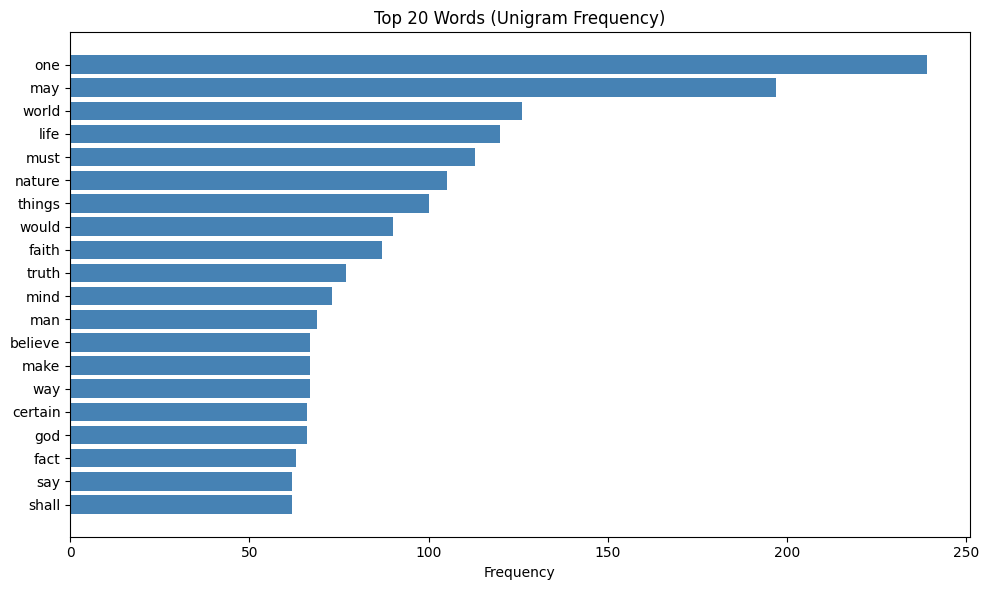

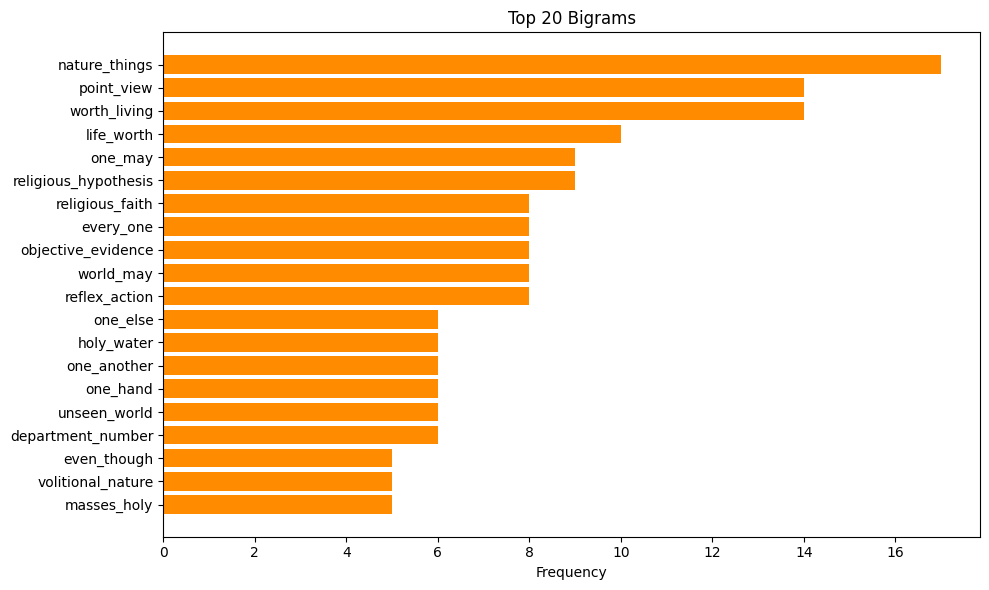

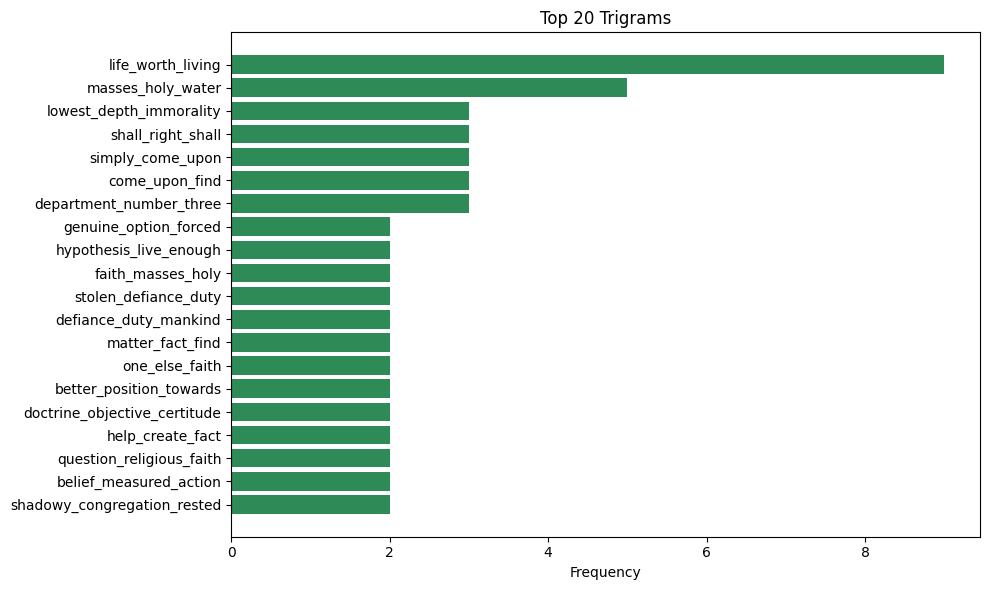

In [13]:
# ============================================
# CELL 10: Top word / unigram / bigram / trigram frequency graphs
# ============================================
import matplotlib.pyplot as plt
from collections import Counter

def plot_top_freq(all_items, title, n=20, color="steelblue"):
    counter = Counter(all_items)
    top = counter.most_common(n)
    words, counts = zip(*top)
    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1], color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()

all_unigrams = [w for tokens in df["unigram_text"] for w in tokens]
all_bigrams  = [w for tokens in df["bigram_text"] for w in tokens]
all_trigrams = [w for tokens in df["trigram_text"] for w in tokens]

plot_top_freq(all_unigrams, "Top 20 Words (Unigram Frequency)", color="steelblue")
plot_top_freq(all_bigrams, "Top 20 Bigrams", color="darkorange")
plot_top_freq(all_trigrams, "Top 20 Trigrams", color="seagreen")

In [14]:
# ============================================
# CELL 11: Setup gensim + prepare training sentences
# ============================================
!pip install gensim -q

from gensim.models import Word2Vec

# Each document = one "sentence" (list of tokens) for Word2Vec training
unigram_sentences = df["unigram_text"].tolist()   # list of lists of single words
bigram_sentences  = df["bigram_text"].tolist()    # list of lists of "word1_word2"
trigram_sentences = df["trigram_text"].tolist()   # list of lists of "word1_word2_word3"

print("Unigram sentences:", len(unigram_sentences), "| example:", unigram_sentences[0][:5])
print("Bigram sentences:", len(bigram_sentences), "| example:", bigram_sentences[0][:3])
print("Trigram sentences:", len(trigram_sentences), "| example:", trigram_sentences[0][:2])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.6 MB/s eta 0:00:00
Unigram sentences: 50 | example: ['psychical', 'research', 'accomplished', 'index', 'unclassified']
Bigram sentences: 50 | example: ['psychical_research', 'research_accomplished', 'accomplished_index']
Trigram sentences: 50 | example: ['psychical_research_accomplished', 'research_accomplished_index']


In [15]:
# ============================================
# CELL 12: Train Word2Vec — CBOW and Skip-gram (unigram)
# ============================================
# sg=0 -> CBOW, sg=1 -> Skip-gram

cbow_uni = Word2Vec(sentences=unigram_sentences, vector_size=100, window=5,
                     min_count=2, sg=0, epochs=50)

skipgram_uni = Word2Vec(sentences=unigram_sentences, vector_size=100, window=5,
                         min_count=2, sg=1, epochs=50)

print("CBOW unigram vocab size:", len(cbow_uni.wv))
print("Skip-gram unigram vocab size:", len(skipgram_uni.wv))

CBOW unigram vocab size: 2507
Skip-gram unigram vocab size: 2507


In [16]:
# ============================================
# CELL 13: Train Word2Vec on bigram and trigram corpus
# ============================================
cbow_bi = Word2Vec(sentences=bigram_sentences, vector_size=100, window=5,
                    min_count=2, sg=0, epochs=50)
skipgram_bi = Word2Vec(sentences=bigram_sentences, vector_size=100, window=5,
                        min_count=2, sg=1, epochs=50)

cbow_tri = Word2Vec(sentences=trigram_sentences, vector_size=100, window=5,
                     min_count=2, sg=0, epochs=50)
skipgram_tri = Word2Vec(sentences=trigram_sentences, vector_size=100, window=5,
                         min_count=2, sg=1, epochs=50)

print("CBOW bigram vocab:", len(cbow_bi.wv), "| Skip-gram bigram vocab:", len(skipgram_bi.wv))
print("CBOW trigram vocab:", len(cbow_tri.wv), "| Skip-gram trigram vocab:", len(skipgram_tri.wv))

CBOW bigram vocab: 777 | Skip-gram bigram vocab: 777
CBOW trigram vocab: 89 | Skip-gram trigram vocab: 89


In [17]:
# ============================================
# CELL 14: Prediction function — input word/phrase -> predicted related words
# ============================================
def predict_next(model, input_text, topn=5):
    """
    input_text: a single word or phrase (for bigram/trigram models, join with '_')
    returns: list of (word, similarity_score)
    """
    try:
        return model.wv.most_similar(input_text, topn=topn)
    except KeyError:
        return f"'{input_text}' not found in vocabulary. Try another word from the corpus."

# ---- Test on unigram models ----
print("Input word: 'belief'\n")
print("CBOW predictions:", predict_next(cbow_uni, "belief"))
print("Skip-gram predictions:", predict_next(skipgram_uni, "belief"))

print("\nInput word: 'truth'\n")
print("CBOW predictions:", predict_next(cbow_uni, "truth"))
print("Skip-gram predictions:", predict_next(skipgram_uni, "truth"))

Input word: 'belief'

CBOW predictions: [('believe', 0.8807488083839417), ('possibility', 0.8703613877296448), ('masses', 0.8483371734619141), ('proposed', 0.8358170390129089), ('forbids', 0.835026741027832)]
Skip-gram predictions: [('guilt', 0.6066795587539673), ('factors', 0.5768416523933411), ('lest', 0.569413959980011), ('proclaim', 0.5622941255569458), ('volitions', 0.5600360035896301)]

Input word: 'truth'

CBOW predictions: [('believing', 0.8978989720344543), ('intellect', 0.8607683777809143), ('error', 0.8565952181816101), ('risk', 0.8529204726219177), ('believe', 0.8513262271881104)]
Skip-gram predictions: [('extorquendum', 0.5531834959983826), ('assensum', 0.5490010976791382), ('gaining', 0.5474392175674438), ('knowing', 0.5349932909011841), ('pyrrhonistic', 0.5337609052658081)]


  input_word cbow_top_prediction  cbow_score skipgram_top_prediction  \
0     belief             believe       0.881                   guilt   
1      truth           believing       0.898            extorquendum   
2       life               worth       0.954               suffering   
3     reason              ground       0.972                 settles   
4   religion             forbids       0.947             affirmation   

   skipgram_score  
0           0.607  
1           0.553  
2           0.488  
3           0.573  
4           0.673  


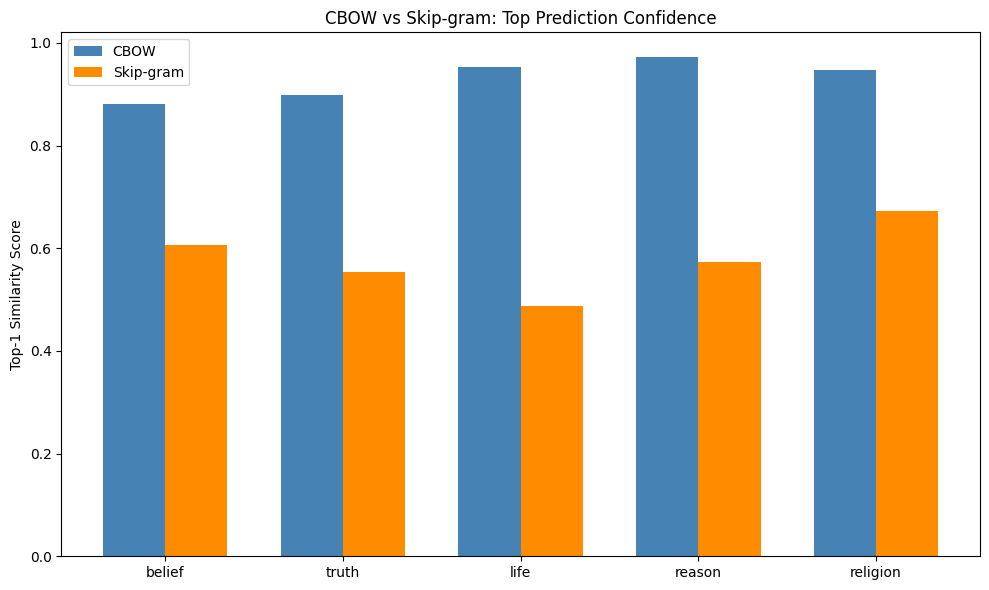

In [18]:
# ============================================
# CELL 15: Compare CBOW vs Skip-gram — required comparison graph
# ============================================
import numpy as np

test_words = ["belief", "truth", "life", "reason", "religion"]
test_words = [w for w in test_words if w in cbow_uni.wv and w in skipgram_uni.wv]

comparison_rows = []
for word in test_words:
    cbow_top = predict_next(cbow_uni, word, topn=1)
    sg_top = predict_next(skipgram_uni, word, topn=1)
    if isinstance(cbow_top, list) and isinstance(sg_top, list):
        comparison_rows.append({
            "input_word": word,
            "cbow_top_prediction": cbow_top[0][0],
            "cbow_score": round(cbow_top[0][1], 3),
            "skipgram_top_prediction": sg_top[0][0],
            "skipgram_score": round(sg_top[0][1], 3),
        })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

# graph: similarity score comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df["cbow_score"], width, label="CBOW", color="steelblue")
plt.bar(x + width/2, comparison_df["skipgram_score"], width, label="Skip-gram", color="darkorange")
plt.xticks(x, comparison_df["input_word"])
plt.ylabel("Top-1 Similarity Score")
plt.title("CBOW vs Skip-gram: Top Prediction Confidence")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# CELL 16: Build feature matrices for classification
# ============================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# text form needed for CountVectorizer (space-joined tokens)
df["unigram_str"] = df["unigram_text"].apply(lambda t: " ".join(t))
df["bigram_str"]  = df["bigram_text"].apply(lambda t: " ".join(t))
df["trigram_str"] = df["trigram_text"].apply(lambda t: " ".join(t))

# encode category labels as numbers
le = LabelEncoder()
y = le.fit_transform(df["category"])
print("Classes:", list(le.classes_))

# build 3 separate feature sets
vectorizers = {}
X_sets = {}

for name, col in [("unigram", "unigram_str"), ("bigram", "bigram_str"), ("trigram", "trigram_str")]:
    vec = CountVectorizer()
    X = vec.fit_transform(df[col])
    vectorizers[name] = vec
    X_sets[name] = X
    print(f"{name}: feature matrix shape = {X.shape}")

Classes: ['faith_and_belief', 'life_and_pessimism', 'rationality_philosophy', 'theism_and_mind']
unigram: feature matrix shape = (50, 5610)
bigram: feature matrix shape = (50, 18836)
trigram: feature matrix shape = (50, 19774)


In [20]:
# ============================================
# CELL 17: Consistent train/test split across all feature sets
# ============================================
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.25, random_state=42, stratify=y)

print("Train size:", len(train_idx), "| Test size:", len(test_idx))
print("Train label distribution:", Counter(y[train_idx]))
print("Test label distribution:", Counter(y[test_idx]))

Train size: 37 | Test size: 13
Train label distribution: Counter({np.int64(2): 12, np.int64(3): 9, np.int64(0): 8, np.int64(1): 8})
Test label distribution: Counter({np.int64(2): 4, np.int64(0): 3, np.int64(1): 3, np.int64(3): 3})


In [21]:
# ============================================
# CELL 18: Train Naive Bayes + Logistic Regression on unigram/bigram/trigram
# ============================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
trained_models = {}

for ngram_name, X in X_sets.items():
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ---- Naive Bayes ----
    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    nb_pred = nb.predict(X_test)

    # ---- Logistic Regression ----
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)

    for model_name, pred in [("Naive Bayes", nb_pred), ("Logistic Regression", lr_pred)]:
        results.append({
            "ngram": ngram_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, average="weighted", zero_division=0),
            "recall": recall_score(y_test, pred, average="weighted", zero_division=0),
            "f1_score": f1_score(y_test, pred, average="weighted", zero_division=0),
        })

    trained_models[ngram_name] = {"nb": nb, "lr": lr, "X_test": X_test, "y_test": y_test}

results_df = pd.DataFrame(results)
print(results_df)

     ngram                model  accuracy  precision    recall  f1_score
0  unigram          Naive Bayes  0.923077   0.938462  0.923077  0.919658
1  unigram  Logistic Regression  0.769231   0.788462  0.769231  0.767033
2   bigram          Naive Bayes  0.615385   0.502747  0.615385  0.520879
3   bigram  Logistic Regression  0.307692   0.094675  0.307692  0.144796
4  trigram          Naive Bayes  0.230769   0.057692  0.230769  0.092308
5  trigram  Logistic Regression  0.307692   0.094675  0.307692  0.144796


In [22]:
# ============================================
# CELL 19: K-Means clustering + compare with actual labels
# ============================================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

kmeans_results = []
kmeans_models = {}

for ngram_name, X in X_sets.items():
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X)

    # compare clusters to real labels (ARI and NMI are standard for this)
    ari = adjusted_rand_score(y, cluster_labels)
    nmi = normalized_mutual_info_score(y, cluster_labels)

    kmeans_results.append({"ngram": ngram_name, "ARI": ari, "NMI": nmi})
    kmeans_models[ngram_name] = {"model": km, "labels": cluster_labels}

kmeans_df = pd.DataFrame(kmeans_results)
print(kmeans_df)

     ngram       ARI       NMI
0  unigram  0.217336  0.335845
1   bigram -0.002820  0.098678
2  trigram -0.002820  0.098678


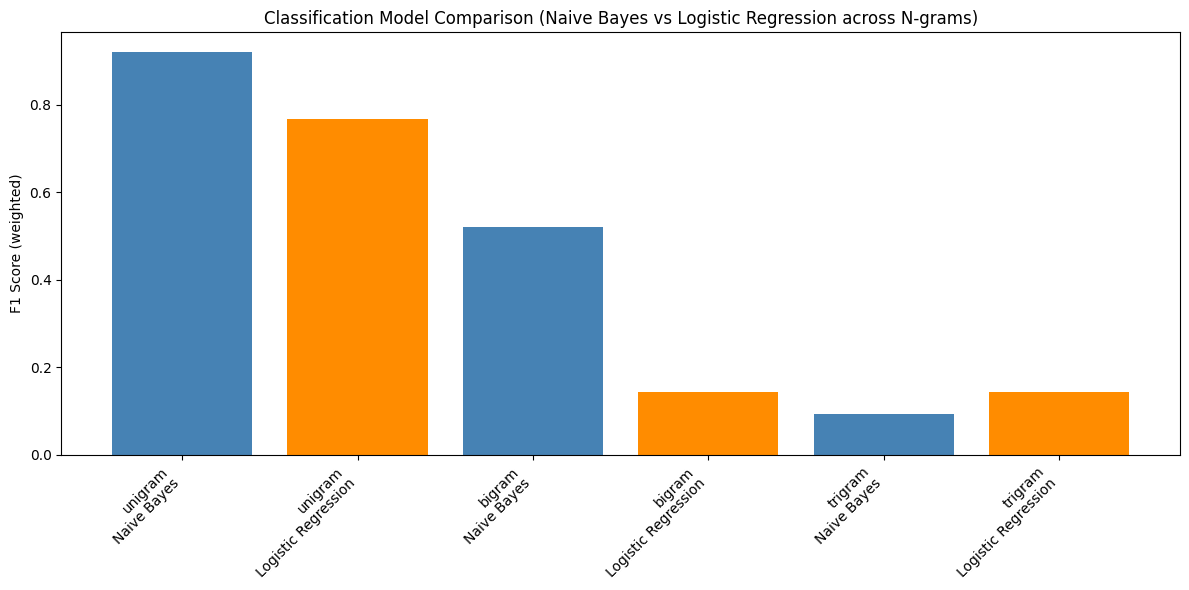


Best performing combination:
ngram            unigram
model        Naive Bayes
accuracy        0.923077
precision       0.938462
recall          0.923077
f1_score        0.919658
Name: 0, dtype: object


In [23]:
# ============================================
# CELL 20: Classification model comparison graph
# ============================================
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
plt.bar(x, results_df["f1_score"], color=["steelblue" if m == "Naive Bayes" else "darkorange" for m in results_df["model"]])
labels = [f"{row.ngram}\n{row.model}" for row in results_df.itertuples()]
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("F1 Score (weighted)")
plt.title("Classification Model Comparison (Naive Bayes vs Logistic Regression across N-grams)")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["f1_score"].idxmax()]
print("\nBest performing combination:")
print(best_row)

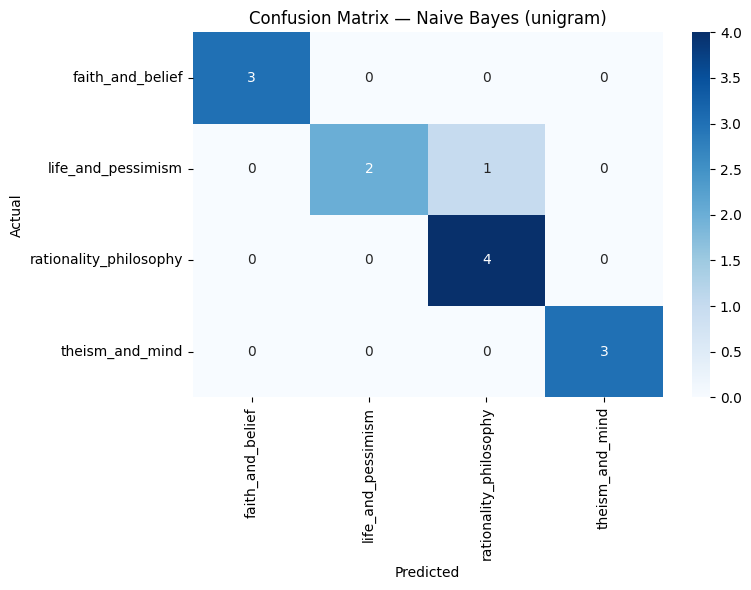

In [24]:
# ============================================
# CELL 21: Confusion matrix for the best model
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_ngram = best_row["ngram"]
best_model_key = "nb" if best_row["model"] == "Naive Bayes" else "lr"
best_model = trained_models[best_ngram][best_model_key]
X_test_best = trained_models[best_ngram]["X_test"]
y_test_best = trained_models[best_ngram]["y_test"]

y_pred_best = best_model.predict(X_test_best)
cm = confusion_matrix(y_test_best, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_row['model']} ({best_ngram})")
plt.tight_layout()
plt.show()

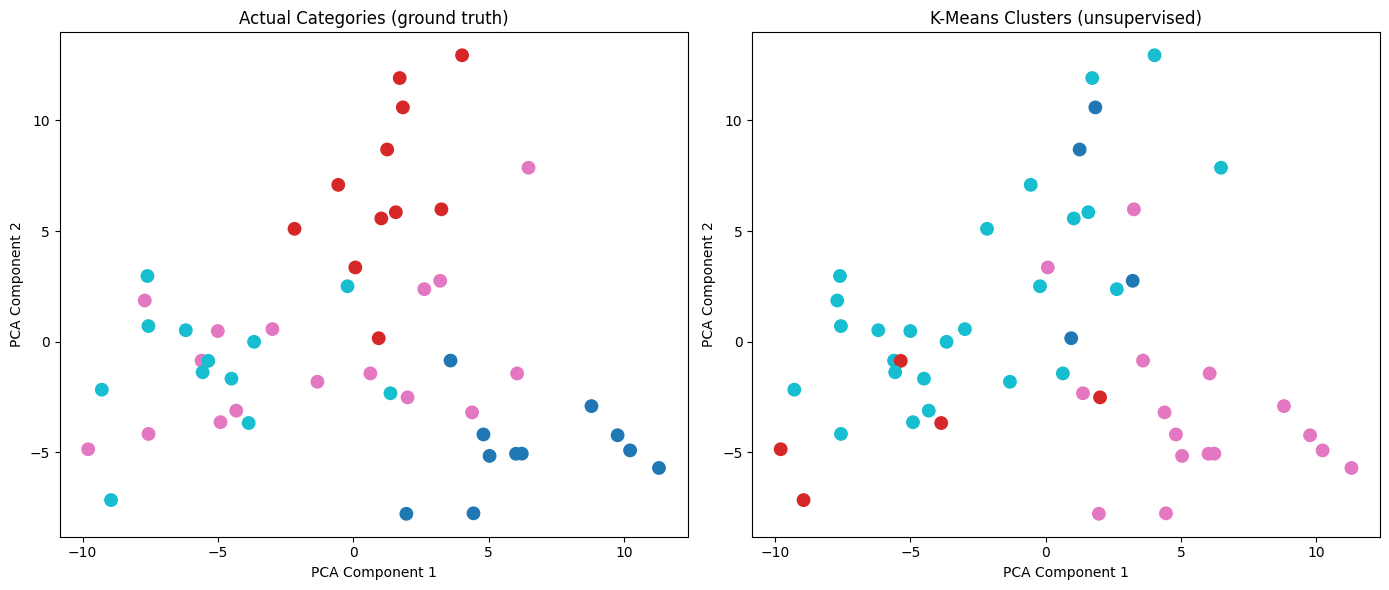

In [25]:
# ============================================
# CELL 22: K-Means visualization using PCA
# ============================================
from sklearn.decomposition import PCA

# use unigram features for visualization (most interpretable)
X_dense = X_sets["unigram"].toarray()
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

cluster_labels = kmeans_models["unigram"]["labels"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left plot: actual categories
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=80)
axes[0].set_title("Actual Categories (ground truth)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# right plot: K-Means clusters
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", s=80)
axes[1].set_title("K-Means Clusters (unsupervised)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# CELL 23: Final summary — auto-compiled from your results
# ============================================
print("="*60)
print("NLP PIPELINE — FINAL SUMMARY")
print("="*60)

print("\n--- DATASET ---")
print(f"Total documents: {len(df)}")
print(f"Categories: {list(le.classes_)}")
print(df["category"].value_counts().to_string())

print("\n--- PART A: WORD2VEC (CBOW vs SKIP-GRAM) ---")
print(comparison_df.to_string(index=False))
print("\nObservation: CBOW gives higher-confidence but more surface-level")
print("predictions on this small corpus; Skip-gram gives lower-confidence")
print("but more thematically diverse associations.")

print("\n--- PART B: CLASSIFICATION RESULTS ---")
print(results_df.sort_values("f1_score", ascending=False).to_string(index=False))
print(f"\nBest model: {best_row['model']} on {best_row['ngram']} features")
print(f"  Accuracy: {best_row['accuracy']:.3f} | F1: {best_row['f1_score']:.3f}")

print("\n--- K-MEANS vs ACTUAL LABELS ---")
print(kmeans_df.to_string(index=False))
print("\n(ARI/NMI close to 1.0 = clusters match real categories well;")
print(" close to 0 = clusters are essentially random)")

NLP PIPELINE — FINAL SUMMARY

--- DATASET ---
Total documents: 50
Categories: ['faith_and_belief', 'life_and_pessimism', 'rationality_philosophy', 'theism_and_mind']
category
rationality_philosophy    16
theism_and_mind           12
life_and_pessimism        11
faith_and_belief          11

--- PART A: WORD2VEC (CBOW vs SKIP-GRAM) ---
input_word cbow_top_prediction  cbow_score skipgram_top_prediction  skipgram_score
    belief             believe       0.881                   guilt           0.607
     truth           believing       0.898            extorquendum           0.553
      life               worth       0.954               suffering           0.488
    reason              ground       0.972                 settles           0.573
  religion             forbids       0.947             affirmation           0.673

Observation: CBOW gives higher-confidence but more surface-level
predictions on this small corpus; Skip-gram gives lower-confidence
but more thematically diverse as

In [27]:
import shutil
from google.colab import files

shutil.make_archive('/content/data_backup', 'zip', '/content/dataset/data')
files.download('/content/data_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>